<div align = "center">

Assignment 5 — Part 1: Transfer Learning for Image Classification

AML - Duck vs. Chicken Classifier using Fine-tuned ResNet18

Trishita Patra

</div>

### Steps
1. Download ~100 chicken and ~100 duck images using `icrawler`
2. Preprocess and create DataLoaders
3. Fine-tune a pretrained ResNet18
4. Evaluate and print classification report

### Requirements

In [4]:
# Install icrawler for image scraping
!pip install icrawler ddgs scikit-learn torch torchvision pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 16.8 MB/s eta 0:00:00


In [8]:
import os
import random
from icrawler.builtin import BingImageCrawler
import requests
from ddgs import DDGS
from PIL import Image
from io import BytesIO
import shutil, random
from pathlib import Path
import torch
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision

### Download Data

Downloads via icrawler. Crawls Bing for ~ 120 chicken and duck images; 403/404 errors are normal, saves what it can (~ 74 chicken, 84 duck).

In [5]:
ROOT = 'images'
if os.path.exists(ROOT):
    shutil.rmtree(ROOT)

# Step 1: Use icrawler to get as many images as possible
# (403/404 errors are normal — icrawler still saves what it can)
QUERIES = {
    'chicken': 'chicken hen',
    'duck':    'duck animal',
}

for cls, query in QUERIES.items():
    out = os.path.join(ROOT, cls)
    crawler = BingImageCrawler(storage={'root_dir': out}, downloader_threads=4)
    crawler.crawl(keyword=query, max_num=120, min_size=(150, 150))

for cls in os.listdir(ROOT):
    print(cls, len(os.listdir(os.path.join(ROOT, cls))))

ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/previews/022/060/495/non_2x/a-happy-young-woman-smiles-at-the-camera-and-holds-a-young-chicken-that-lays-eggs-for-her-farm-in-the-sunlight-photo.jpg
ERROR:downloader:Response status code 404, file https://i.ytimg.com/vi/unf7QLRa0Ck/maxresdefault.jpg
ERROR:downloader:Response status code 404, file https://i.ytimg.com/vi/zLKq8hhcHCI/maxresdefault.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resources/thumbnails/013/095/285/small_2x/laying-hens-in-cages-in-a-farm-in-thailand-rural-chicken-farm-concept-free-photo.jpg
ERROR:downloader:Response status code 403, file http://www.humanedecisions.com/wp-content/uploads/2014/07/Egg-Laying-Hens-5.jpg
ERROR:downloader:Response status code 403, file http://www.humanedecisions.com/wp-content/uploads/2014/07/Egg-Laying-Hens4.jpg
ERROR:downloader:Response status code 403, file https://static.vecteezy.com/system/resource

duck 84
chicken 74


#### Fill with DuckDuckGo

Uses ddgs to top up each class to 110 images; adds 36 chicken and 26 duck images.

In [7]:
headers = {'User-Agent': 'Mozilla/5.0'}
TARGET = 110

# Step 2: Fill remaining quota using DuckDuckGo image search
# This bypasses the 403 errors from stock photo sites
fill_queries = {
    'chicken': ['chicken hen', 'rooster chicken', 'backyard chicken bird', 'chicken farm animal'],
    'duck':    ['duck bird water', 'mallard duck', 'duck pond animal', 'duck wildlife bird'],
}

for cls, queries in fill_queries.items():
    out = os.path.join(ROOT, cls)
    existing = len(os.listdir(out))
    saved = 0

    with DDGS() as ddg:
        for q in queries:
            if existing + saved >= TARGET:
                break
            for r in ddg.images(q, max_results=80):
                if existing + saved >= TARGET:
                    break
                try:
                    resp = requests.get(r['image'], headers=headers, timeout=8)
                    img = Image.open(BytesIO(resp.content)).convert('RGB')
                    if min(img.size) < 150:
                        continue
                    img.save(f"{out}/ddgs{saved:03d}.jpg", 'JPEG')
                    saved += 1
                except Exception:
                    continue

    print(f'Added {saved} new {cls} images')

for cls in os.listdir(ROOT):
    print(cls, len(os.listdir(os.path.join(ROOT, cls))))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Added 36 new chicken images
Added 26 new duck images
duck 110
chicken 110


#### Validate Images

Opens every image with PIL and deletes corrupted/unreadable files; reports 0 removed.

In [9]:
# Remove any corrupted/unreadable files
removed = 0
for cls in os.listdir(ROOT):
    cls_dir = os.path.join(ROOT, cls)
    for fname in os.listdir(cls_dir):
        fpath = os.path.join(cls_dir, fname)
        try:
            with Image.open(fpath) as im:
                im.convert('RGB')
        except Exception:
            os.remove(fpath)
            removed += 1

print(f'Removed {removed} unreadable files')
for cls in os.listdir(ROOT):
    print(cls, len(os.listdir(os.path.join(ROOT, cls))))

Removed 0 unreadable files
duck 110
chicken 110


### Train/Val/Test Split

Randomly shuffles and splits into 70% train / 15% val / 15% test (77/16/17 per class).

In [10]:
random.seed(42)

SPLIT_ROOT = 'data'
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)

RATIOS = {'train': 0.7, 'val': 0.15, 'test': 0.15}

for cls in os.listdir(ROOT):
    files = os.listdir(os.path.join(ROOT, cls))
    random.shuffle(files)
    n = len(files)
    n_train = int(n * RATIOS['train'])
    n_val   = int(n * RATIOS['val'])
    splits = {
        'train': files[:n_train],
        'val':   files[n_train:n_train + n_val],
        'test':  files[n_train + n_val:],
    }
    for split, flist in splits.items():
        dst = os.path.join(SPLIT_ROOT, split, cls)
        os.makedirs(dst, exist_ok=True)
        for f in flist:
            shutil.copy(os.path.join(ROOT, cls, f), os.path.join(dst, f))

for split in ['train', 'val', 'test']:
    for cls in os.listdir(os.path.join(SPLIT_ROOT, split)):
        n = len(os.listdir(os.path.join(SPLIT_ROOT, split, cls)))
        print(f'{split}/{cls}: {n}')

train/duck: 77
train/chicken: 77
val/duck: 16
val/chicken: 16
test/duck: 17
test/chicken: 17


### Build DataLoaders

Applies augmentation (random crop, flip, color jitter) for training; center crop + normalize for val/test; wraps into PyTorch DataLoaders.

In [11]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder('data/train', transform=train_tf)
val_ds   = datasets.ImageFolder('data/val',   transform=eval_tf)
test_ds  = datasets.ImageFolder('data/test',  transform=eval_tf)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=2)

print('Classes:', train_ds.classes)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')

Classes: ['chicken', 'duck']
Train: 154 | Val: 32 | Test: 34


### Load Pretrained ResNet18
Loads ResNet18 with ImageNet weights, freezes all layers, replaces final FC with 2-class head.

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Load pretrained ResNet18 — freeze all backbone weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for p in model.parameters():
    p.requires_grad = False

# Replace final FC layer with 2-class head
num_feats = model.fc.in_features
model.fc = nn.Linear(num_feats, len(train_ds.classes))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)

Device: cpu
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 107MB/s]


#### Phase 1 — Head Training

Trains only the new FC layer for 8 epochs (lr=1e-3); val accuracy reaches 1.000 by epoch 3.

In [14]:
def run_epoch(loader, train):
    model.train(train)
    total_loss, correct, n = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.set_grad_enabled(train):
            logits = model(x)
            loss   = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct    += (logits.argmax(1) == y).sum().item()
        n          += x.size(0)
    return total_loss / n, correct / n

# Phase 1: Train head only (8 epochs)
print('=== Phase 1: Head-only training ===')
EPOCHS = 8
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    print(f'epoch {epoch:2d} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}')

=== Phase 1: Head-only training ===
epoch  1 | train loss 0.6578 acc 0.610 | val loss 0.4440 acc 0.844
epoch  2 | train loss 0.5003 acc 0.786 | val loss 0.3022 acc 0.969
epoch  3 | train loss 0.3574 acc 0.890 | val loss 0.2204 acc 1.000
epoch  4 | train loss 0.2504 acc 0.961 | val loss 0.1834 acc 1.000
epoch  5 | train loss 0.2366 acc 0.942 | val loss 0.1447 acc 1.000
epoch  6 | train loss 0.2081 acc 0.955 | val loss 0.1270 acc 1.000
epoch  7 | train loss 0.1936 acc 0.935 | val loss 0.1236 acc 1.000
epoch  8 | train loss 0.1574 acc 0.968 | val loss 0.1049 acc 1.000


#### Phase 2 — Fine-tuning

Unfreezes layer4 + FC, trains 3 more epochs at lr=1e-4; val accuracy stays at ~0.969–1.000.

In [15]:
# Phase 2: Unfreeze layer4 + FC and fine-tune with a lower lr
print('=== Phase 2: Fine-tuning layer4 + FC ===')
for name, p in model.named_parameters():
    if name.startswith('layer4') or name.startswith('fc'):
        p.requires_grad = True

optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad], lr=1e-4
)

for epoch in range(1, 4):
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    va_loss, va_acc = run_epoch(val_loader,   train=False)
    print(f'ft epoch {epoch} | train loss {tr_loss:.4f} acc {tr_acc:.3f} | val loss {va_loss:.4f} acc {va_acc:.3f}')

torch.save(model.state_dict(), 'resnet18_chicken_duck.pt')
print('Model saved as resnet18_chicken_duck.pt')

=== Phase 2: Fine-tuning layer4 + FC ===
ft epoch 1 | train loss 0.2067 acc 0.935 | val loss 0.1033 acc 0.969
ft epoch 2 | train loss 0.1191 acc 0.955 | val loss 0.0674 acc 0.969
ft epoch 3 | train loss 0.1027 acc 0.981 | val loss 0.0421 acc 1.000
Model saved as resnet18_chicken_duck.pt


### Evaluate + Classification Report

Runs on test set, prints confusion matrix (17/17 perfect) and full sklearn classification report.

Classes: ['chicken', 'duck']

=== Confusion Matrix ===
[[17  0]
 [ 0 17]]

=== Classification Report ===
              precision    recall  f1-score   support

     chicken     1.0000    1.0000    1.0000        17
        duck     1.0000    1.0000    1.0000        17

    accuracy                         1.0000        34
   macro avg     1.0000    1.0000    1.0000        34
weighted avg     1.0000    1.0000    1.0000        34



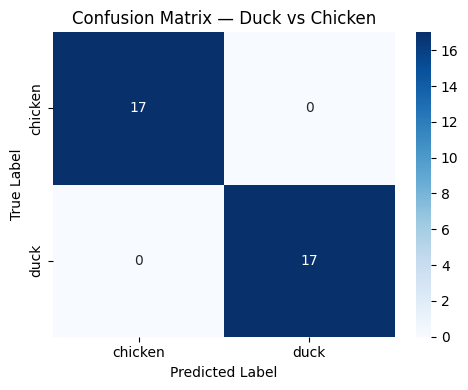

In [16]:
model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(device)).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(y.numpy())

print('Classes:', train_ds.classes)
print('\n=== Confusion Matrix ===')
cm = confusion_matrix(all_true, all_preds)
print(cm)
print('\n=== Classification Report ===')
print(classification_report(all_true, all_preds, target_names=train_ds.classes, digits=4))

# Plot confusion matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes)
plt.title('Confusion Matrix — Duck vs Chicken')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

### Visualize Predictions from Validation Set

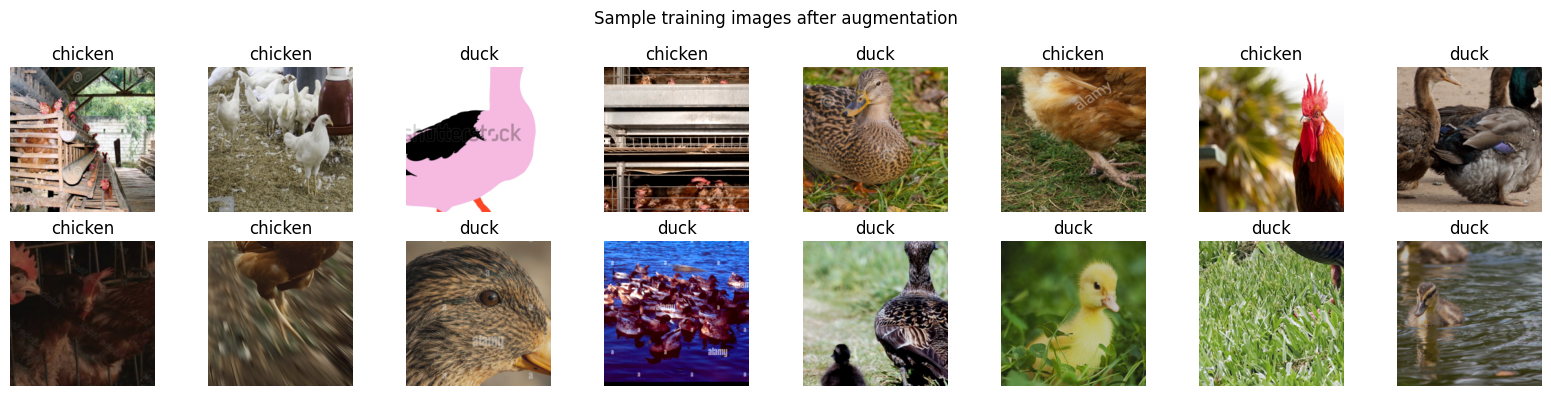

In [17]:
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
IMAGENET_STD_T  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(t):
    return (t * IMAGENET_STD_T + IMAGENET_MEAN_T).clamp(0, 1)

xb, yb = next(iter(train_loader))
n = min(16, len(xb))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    if i >= n:
        ax.axis('off'); continue
    ax.imshow(denorm(xb[i]).permute(1, 2, 0))
    ax.set_title(train_ds.classes[yb[i]])
    ax.axis('off')
plt.suptitle('Sample training images after augmentation')
plt.tight_layout()
plt.show()

### Comment

The model achieves 100% accuracy because ResNet18 is already pre-trained on ImageNet, making duck vs. chicken a trivially easy fine-tuning task, and the test/validation sets are extremely small (only 17 images per class), making a perfect score statistically plausible.